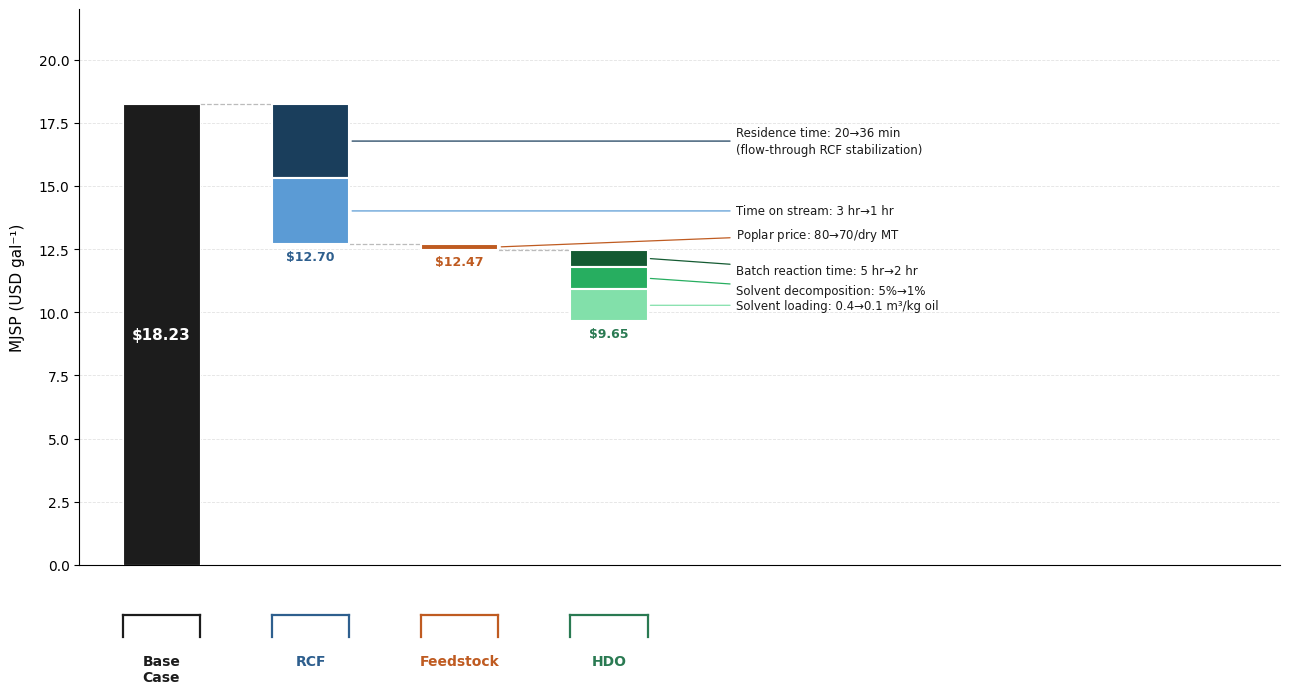

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.transforms import blended_transform_factory

# ─── Data ────────────────────────────────────────────────────────────────────
base_val = 18.23

# (label, resulting_mjsp, color, category_group_x, category_name)
# RCF: 2 shades of blue  |  Feedstock: orange  |  HDO: 3 shades of green
segs = [
    ("Residence time: 20→36 min\n(flow-through RCF stabilization)", 15.32, "#1A3E5C", 1, "RCF"),
    ("Time on stream: 3 hr→1 hr",                                    12.70, "#5B9BD5", 1, "RCF"),
    ("Poplar price: $80→$70/dry MT",                                  12.47, "#BF5B21", 2, "Feedstock"),
    ("Batch reaction time: 5 hr→2 hr",                               11.79, "#145A32", 3, "HDO"),
    ("Solvent decomposition: 5%→1%",                                 10.90, "#27AE60", 3, "HDO"),
    ("Solvent loading: 0.4→0.1 m³/kg oil",                            9.65, "#82E0AA", 3, "HDO"),
]

cat_main = {0: "#1C1C1C", 1: "#2E5F8E", 2: "#BF5B21", 3: "#2A7A52"}
cat_name = {0: "Base\nCase", 1: "RCF", 2: "Feedstock", 3: "HDO"}

# Build segments: compute bottom & height from sequential values
current = base_val
seg_data = []
for lbl, nv, col, xg, cat in segs:
    seg_data.append({"x": xg, "bottom": nv, "height": current - nv,
                      "color": col, "label": lbl, "val": nv, "cat": cat})
    current = nv

# End value per x group
end_val = {0: base_val, 1: 12.70, 2: 12.47, 3: 9.65}

# ─── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
fig.subplots_adjust(bottom=0.20, right=0.97, left=0.08, top=0.95)

# ─── Base bar ────────────────────────────────────────────────────────────────
ax.bar(0, base_val, bottom=0, color="#1C1C1C", width=0.52,
       edgecolor="white", linewidth=0.8, zorder=3)
ax.text(0, base_val / 2, f"${base_val:.2f}",
        ha="center", va="center", fontsize=11, fontweight="bold",
        color="white", zorder=4)

# ─── Stacked reduction bars ───────────────────────────────────────────────────
# Segments at the same x are vertically adjacent → form a visual stack.
# edgecolor="white" with linewidth=1.5 creates a visible seam between sub-segments.
for s in seg_data:
    ax.bar(s["x"], s["height"], bottom=s["bottom"],
           color=s["color"], width=0.52,
           edgecolor="white", linewidth=1.5, zorder=3)

# ─── Group end-value labels (below each stacked bar) ─────────────────────────
for x in [1, 2, 3]:
    ax.text(x, end_val[x] - 0.22, f"${end_val[x]:.2f}",
            ha="center", va="top", fontsize=9, fontweight="bold",
            color=cat_main[x], zorder=4, clip_on=False)

# ─── Connector dashed lines between bar groups ───────────────────────────────
# Shows the carry-forward MJSP floor from one group to the next
for (x_from, x_to, y_level) in [
    (0, 1, base_val),  # Base → RCF:      both tops at 18.23
    (1, 2, 12.70),     # RCF → Feedstock: floor at 12.70
    (2, 3, 12.47),     # Feedstock → HDO: floor at 12.47
]:
    ax.plot([x_from + 0.26, x_to - 0.26], [y_level, y_level],
            color="#BBBBBB", linestyle="--", linewidth=0.9, zorder=2)

# ─── Annotations with leader lines (right side) ──────────────────────────────
# y-offsets prevent label crowding where segments are close together
ann_y_adj = {0: 0.0, 1: 0.0, 2: 0.5, 3: -0.5, 4: -0.5, 5: 0.0}
ann_x = 3.85  # annotation text x-start in data coordinates

for i, s in enumerate(seg_data):
    y_bar = s["bottom"] + s["height"] / 2
    y_txt = y_bar + ann_y_adj[i]
    ax.annotate(
        s["label"],
        xy=(s["x"] + 0.26, y_bar),
        xytext=(ann_x, y_txt),
        fontsize=8.5, ha="left", va="center", color="#1A1A1A",
        arrowprops=dict(arrowstyle="-", color=s["color"], lw=0.9,
                        connectionstyle="arc3,rad=0"),
        clip_on=False, zorder=5, linespacing=1.4,
    )

# ─── Axes styling ─────────────────────────────────────────────────────────────
ax.set_ylabel("MJSP (USD gal⁻¹)", fontsize=11, labelpad=10)
ax.set_ylim(0, 22)
ax.set_xlim(-0.55, 7.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", bottom=False, labelbottom=False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.35, zorder=0)
ax.set_axisbelow(True)

# ─── Group bracket labels below x-axis ───────────────────────────────────────
blend = blended_transform_factory(ax.transData, ax.transAxes)
y_hl, y_tk, y_lb = -0.09, -0.13, -0.16

for xg in [0, 1, 2, 3]:
    xl = xg - 0.26
    xr = xg + 0.26
    col = cat_main[xg]
    ax.plot([xl, xr], [y_hl, y_hl], color=col, lw=1.6,
            transform=blend, clip_on=False)
    for xv in [xl, xr]:
        ax.plot([xv, xv], [y_hl, y_tk], color=col, lw=1.6,
                transform=blend, clip_on=False)
    ax.text(xg, y_lb, cat_name[xg], transform=blend,
            ha="center", va="top", fontsize=10, fontweight="bold",
            color=col, clip_on=False, multialignment="center")

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig("mjsp_waterfall2.svg", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()